# HepatoCryoAI — Rede Neural (PyTorch)

**Pipeline:**
1. Análise Exploratória e Importância de Variáveis
2. Engenharia de Features (Polinomiais)
3. Arquitetura da Rede Neural (PyTorch)
4. Treinamento com Early Stopping e Learning Rate Scheduling
5. Avaliação (R², RMSE, Validação Cruzada K-Fold)
6. Visualizações e Exportação do Modelo

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

# Configuração visual
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

# Reprodutibilidade
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {DEVICE}')
print(f'PyTorch: {torch.__version__}')

Dispositivo: cpu
PyTorch: 2.11.0+cpu


## Carregamento

In [2]:
# Carregar dados
df = pd.read_csv('../data/raw/hepg2.csv')
print(f'Dataset: {df.shape[0]} amostras, {df.shape[1]} colunas')
print(f'Colunas: {list(df.columns)}\n')

df.describe().round(2)

Dataset: 216 amostras, 6 colunas
Colunas: ['INDEX', 'ESPÉCIE/LINHAGEM', '% DMSO', 'TREHALOSE', '% SFB', 'VIABILIDADE']



,INDEX,% DMSO,TREHALOSE,% SFB,VIABILIDADE
count,216.00,216.00,216.00,216.00,216.00
mean,108.50,20.74,16.94,58.98,44.33
std,62.50,27.95,26.82,30.56,36.87
min,1.00,0.00,0.00,0.00,0.00
25%,54.75,2.00,0.00,40.00,0.00
50%,108.50,5.00,0.00,70.00,54.44
75%,162.25,30.00,30.00,81.25,76.78
max,216.00,100.00,100.00,100.00,97.33


In [3]:
# Verificar dependência linear entre variáveis
# SFB = 100 - DMSO - TREHALOSE (na maioria dos casos)
# SFB é linearmente dependente de DMSO e TREHALOSE. Incluí-lo como feature adicionaria multicolinearidade sem informação nova.
df['SOMA'] = df['% DMSO'] + df['TREHALOSE'] + df['% SFB']
print('Soma DMSO + TREHALOSE + SFB:')
print(df['SOMA'].value_counts())
df.drop('SOMA', axis=1, inplace=True)

Soma DMSO + TREHALOSE + SFB:
SOMA
100.0    208
10.0       8
Name: count, dtype: int64


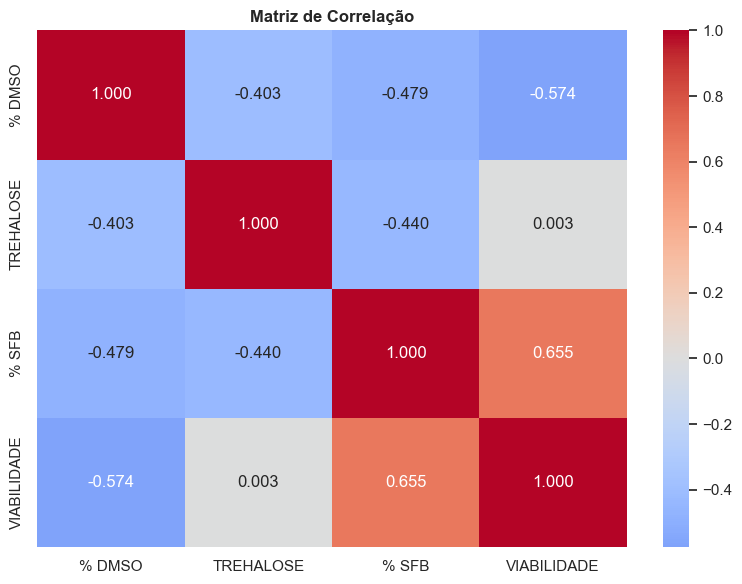

In [4]:
# Matriz de correlação
fig, ax = plt.subplots(figsize=(8, 6))
corr = df[['% DMSO', 'TREHALOSE', '% SFB', 'VIABILIDADE']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.3f', ax=ax)
ax.set_title('Matriz de Correlação', fontweight='bold')
plt.tight_layout()
plt.savefig('validation_images/nn_correlacao.png', dpi=300)
plt.show()

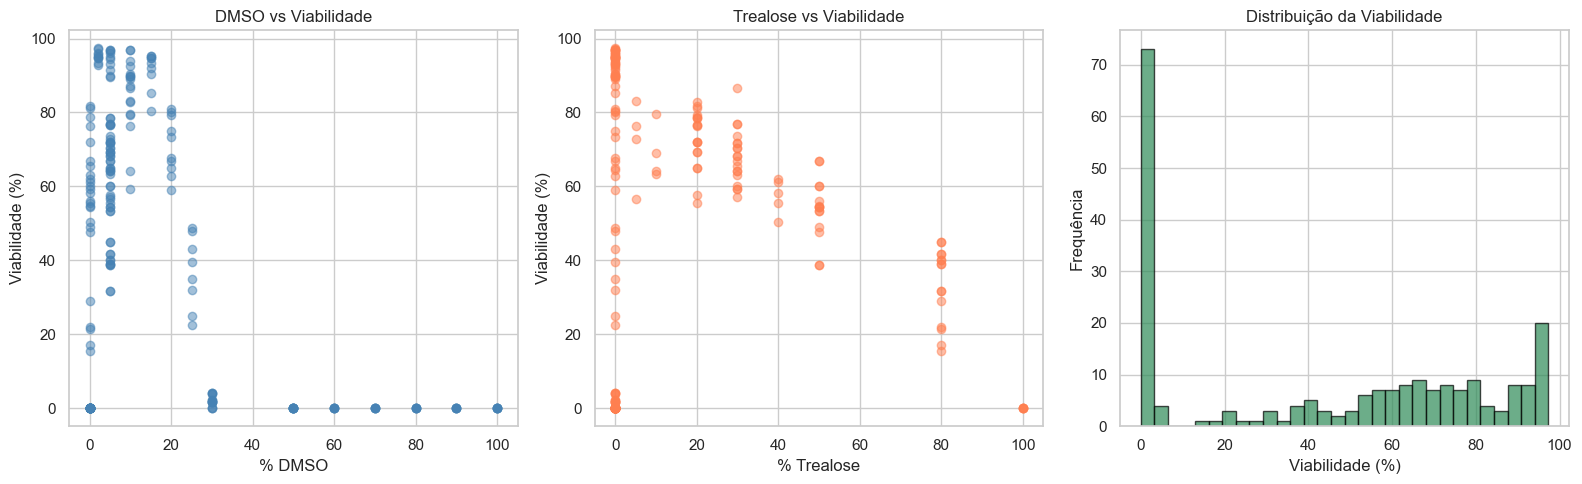

In [5]:
# Distribuição da viabilidade
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].scatter(df['% DMSO'], df['VIABILIDADE'], alpha=0.5, c='steelblue')
axes[0].set_xlabel('% DMSO')
axes[0].set_ylabel('Viabilidade (%)')
axes[0].set_title('DMSO vs Viabilidade')

axes[1].scatter(df['TREHALOSE'], df['VIABILIDADE'], alpha=0.5, c='coral')
axes[1].set_xlabel('% Trealose')
axes[1].set_ylabel('Viabilidade (%)')
axes[1].set_title('Trealose vs Viabilidade')

axes[2].hist(df['VIABILIDADE'], bins=30, color='seagreen', edgecolor='black', alpha=0.7)
axes[2].set_xlabel('Viabilidade (%)')
axes[2].set_ylabel('Frequência')
axes[2].set_title('Distribuição da Viabilidade')

plt.tight_layout()
plt.savefig('validation_images/nn_distribuicao.png', dpi=300)
plt.show()

## Feature Importance

In [6]:
# Features originais
X_raw = df[['% DMSO', 'TREHALOSE']].values
y = df['VIABILIDADE'].values

# Feature importance com Random Forest (features cruas)
rf_temp = RandomForestRegressor(n_estimators=200, random_state=SEED)
rf_temp.fit(X_raw, y)
print('Feature Importance (variáveis brutas):')
for name, imp in zip(['% DMSO', 'TREHALOSE'], rf_temp.feature_importances_):
    print(f'  {name}: {imp:.4f}')

Feature Importance (variáveis brutas):
  % DMSO: 0.7662
  TREHALOSE: 0.2338


Features originais: 2 -> Features polinomiais: 5
Nomes: ['DMSO', 'TREHALOSE', 'DMSO^2', 'DMSO TREHALOSE', 'TREHALOSE^2']

Feature Importance (com termos polinomiais):
  DMSO^2              : 0.4201
  DMSO                : 0.3460
  TREHALOSE           : 0.1094
  TREHALOSE^2         : 0.1009
  DMSO TREHALOSE      : 0.0237


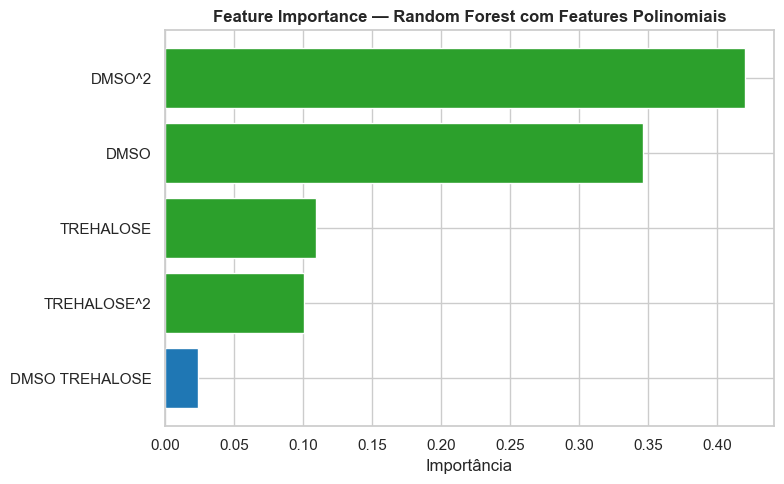

In [7]:
# Engenharia de Features: termos polinomiais de grau 2
# Isso captura: DMSO², TREHALOSE², DMSO × TREHALOSE

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_raw)
feature_names = poly.get_feature_names_out(['DMSO', 'TREHALOSE'])

print(f'Features originais: 2 -> Features polinomiais: {X_poly.shape[1]}')
print(f'Nomes: {list(feature_names)}\n')

# Feature importance com features polinomiais
rf_poly = RandomForestRegressor(n_estimators=200, random_state=SEED)
rf_poly.fit(X_poly, y)

importances = rf_poly.feature_importances_
indices = np.argsort(importances)[::-1]

print('Feature Importance (com termos polinomiais):')
for i in indices:
    print(f'  {feature_names[i]:20s}: {importances[i]:.4f}')

# Gráfico
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#2ca02c' if imp > 0.1 else '#1f77b4' for imp in importances[indices]]
ax.barh(range(len(indices)), importances[indices], color=colors)
ax.set_yticks(range(len(indices)))
ax.set_yticklabels([feature_names[i] for i in indices])
ax.set_xlabel('Importância')
ax.set_title('Feature Importance — Random Forest com Features Polinomiais', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('validation_images/nn_feature_importance.png', dpi=300)
plt.show()

## Dados

In [8]:
# Divisão treino/teste (80/20) — mesma divisão usada no Random Forest
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=SEED
)

# Engenharia de features (fit no treino, transform no teste)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_raw)
X_test_poly = poly.transform(X_test_raw)

# Padronização (fit no treino, transform no teste)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_poly)
X_test_scaled = scaler.transform(X_test_poly)

print(f'Treino: {X_train_scaled.shape[0]} amostras, {X_train_scaled.shape[1]} features')
print(f'Teste:  {X_test_scaled.shape[0]} amostras, {X_test_scaled.shape[1]} features')

# Converter para tensores PyTorch
X_train_t = torch.FloatTensor(X_train_scaled).to(DEVICE)
y_train_t = torch.FloatTensor(y_train).unsqueeze(1).to(DEVICE)
X_test_t = torch.FloatTensor(X_test_scaled).to(DEVICE)
y_test_t = torch.FloatTensor(y_test).unsqueeze(1).to(DEVICE)

# DataLoader para mini-batch training
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

Treino: 172 amostras, 5 features
Teste:  44 amostras, 5 features


## Rede Neural

- **Camada de entrada**: 5 neurônios (DMSO, Trealose, DMSO², DMSO×Trealose, Trealose²)
- **3 camadas ocultas**: 128 → 64 → 32 neurônios
- **Batch Normalization** em cada camada (estabiliza o treinamento)
- **Dropout** (20%) para regularização e prevenção de overfitting
- **Ativação ReLU** nas camadas ocultas
- **Camada de saída**: 1 neurônio (viabilidade celular %)

In [9]:
class HepatoCryoNN(nn.Module):    
    def __init__(self, input_dim=5, dropout_rate=0.2):
        super(HepatoCryoNN, self).__init__()
        
        self.network = nn.Sequential(
            # Camada 1: input -> 128
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            # Camada 2: 128 -> 64
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            # Camada 3: 64 -> 32
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            # Saída: 32 -> 1
            nn.Linear(32, 1)
        )
    
    def forward(self, x):
        return self.network(x)


# Instanciar modelo
model = HepatoCryoNN(input_dim=X_train_scaled.shape[1]).to(DEVICE)

# Contar parâmetros
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parâmetros totais: {total_params:,}')
print(f'Parâmetros treináveis: {trainable_params:,}\n')
print(model)

Parâmetros totais: 11,585
Parâmetros treináveis: 11,585

HepatoCryoNN(
  (network): Sequential(
    (0): Linear(in_features=5, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=32, out_features=1, bias=True)
  )
)


## Treinamento

In [10]:
# Hiperparâmetros de treinamento
EPOCHS = 2000
LEARNING_RATE = 0.001
WEIGHT_DECAY = 1e-4       # Regularização L2
PATIENCE = 100             # Early stopping: parar se não melhorar em 100 épocas

# Função de perda e otimizador
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# Learning Rate Scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=30, min_lr=1e-6
)

In [11]:
# LOOP DE TREINAMENTO

train_losses = []
test_losses = []
best_test_loss = float('inf')
best_epoch = 0
epochs_without_improvement = 0

for epoch in range(EPOCHS):
    # --- TREINO ---
    model.train()
    epoch_train_loss = 0.0
    n_batches = 0
    
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()
        n_batches += 1
    
    avg_train_loss = epoch_train_loss / n_batches
    train_losses.append(avg_train_loss)
    
    # --- AVALIAÇÃO NO TESTE ---
    model.eval()
    with torch.no_grad():
        y_test_pred = model(X_test_t)
        test_loss = criterion(y_test_pred, y_test_t).item()
    test_losses.append(test_loss)
    
    # Learning Rate Scheduler
    scheduler.step(test_loss)
    
    # Early Stopping
    if test_loss < best_test_loss:
        best_test_loss = test_loss
        best_epoch = epoch
        epochs_without_improvement = 0
        # Salvar melhor modelo
        torch.save(model.state_dict(), 'best_nn_model.pth')
    else:
        epochs_without_improvement += 1
    
    if epochs_without_improvement >= PATIENCE:
        print(f'\nEarly stopping na época {epoch}. Melhor época: {best_epoch}')
        break
    
    # Log a cada 100 épocas
    if (epoch + 1) % 100 == 0:
        print(f'Época {epoch+1:4d}/{EPOCHS} | '
              f'Train Loss: {avg_train_loss:.4f} | '
              f'Test Loss: {test_loss:.4f} | '
              f'LR: {optimizer.param_groups[0]["lr"]:.6f}')

print(f'\nTreinamento concluído. Melhor época: {best_epoch} (Test Loss: {best_test_loss:.4f})')

Época  100/2000 | Train Loss: 1095.0488 | Test Loss: 727.7860 | LR: 0.001000
Época  200/2000 | Train Loss: 418.4668 | Test Loss: 131.0042 | LR: 0.001000
Época  300/2000 | Train Loss: 314.6864 | Test Loss: 93.6649 | LR: 0.000500
Época  400/2000 | Train Loss: 287.5102 | Test Loss: 85.4931 | LR: 0.000063
Época  500/2000 | Train Loss: 273.1315 | Test Loss: 79.4640 | LR: 0.000016

Early stopping na época 545. Melhor época: 445

Treinamento concluído. Melhor época: 445 (Test Loss: 73.1957)


In [12]:
# Carregar o melhor modelo salvo
model.load_state_dict(torch.load('best_nn_model.pth'))
model.eval()

HepatoCryoNN(
  (network): Sequential(
    (0): Linear(in_features=5, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=32, out_features=1, bias=True)
  )
)

## Avaliação

In [13]:
# Predições finais
model.eval()
with torch.no_grad():
    y_pred_train = model(X_train_t).cpu().numpy().flatten()
    y_pred_test = model(X_test_t).cpu().numpy().flatten()

# Métricas
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

print('MÉTRICAS DE DESEMPENHO — REDE NEURAL (PyTorch)\n')
print(f'Treino -> R² = {r2_train:.4f} | RMSE = {rmse_train:.2f}%')
print(f'Teste  -> R² = {r2_test:.4f} | RMSE = {rmse_test:.2f}%')

MÉTRICAS DE DESEMPENHO — REDE NEURAL (PyTorch)

Treino -> R² = 0.9071 | RMSE = 11.33%
Teste  -> R² = 0.9412 | RMSE = 8.56%


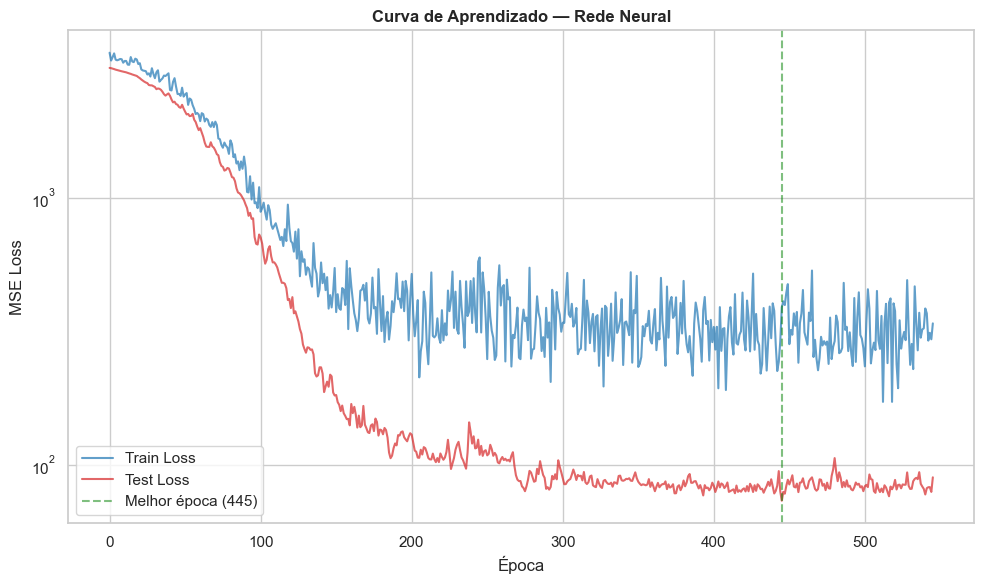

In [14]:
# Curva de Loss (Treinamento vs Teste)
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(train_losses, label='Train Loss', color='#1f77b4', alpha=0.7)
ax.plot(test_losses, label='Test Loss', color='#d62728', alpha=0.7)
ax.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.5, label=f'Melhor época ({best_epoch})')
ax.set_xlabel('Época')
ax.set_ylabel('MSE Loss')
ax.set_title('Curva de Aprendizado — Rede Neural', fontweight='bold')
ax.legend()
ax.set_yscale('log')  # Escala log para visualizar convergência
plt.tight_layout()
plt.savefig('validation_images/nn_curva_loss.png', dpi=300)
plt.show()

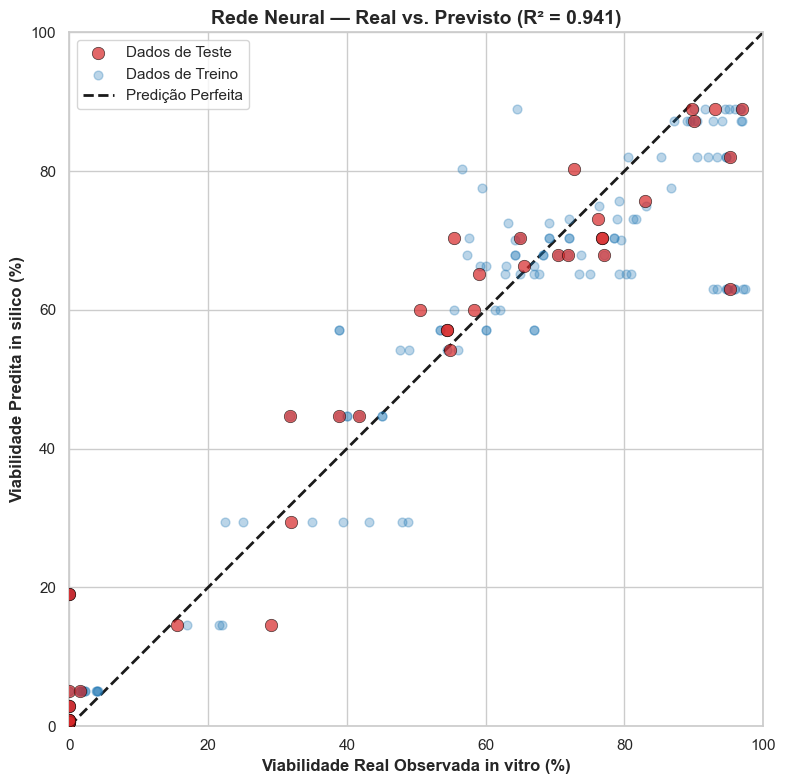

In [15]:
# Gráfico: Real vs Previsto
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(y_test, y_pred_test, alpha=0.7, color='#d62728', s=80, 
           edgecolors='black', linewidths=0.5, label='Dados de Teste', zorder=3)
ax.scatter(y_train, y_pred_train, alpha=0.3, color='#1f77b4', s=40, 
           label='Dados de Treino', zorder=2)

# Linha perfeita
lims = [min(y.min(), 0), max(y.max(), 100)]
ax.plot(lims, lims, 'k--', lw=2, label='Predição Perfeita', zorder=1)

ax.set_xlabel('Viabilidade Real Observada in vitro (%)', fontweight='bold')
ax.set_ylabel('Viabilidade Predita in silico (%)', fontweight='bold')
ax.set_title(f'Rede Neural — Real vs. Previsto (R² = {r2_test:.3f})', fontweight='bold', fontsize=14)
ax.legend()
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('validation_images/nn_real_vs_previsto.png', dpi=300)
plt.show()

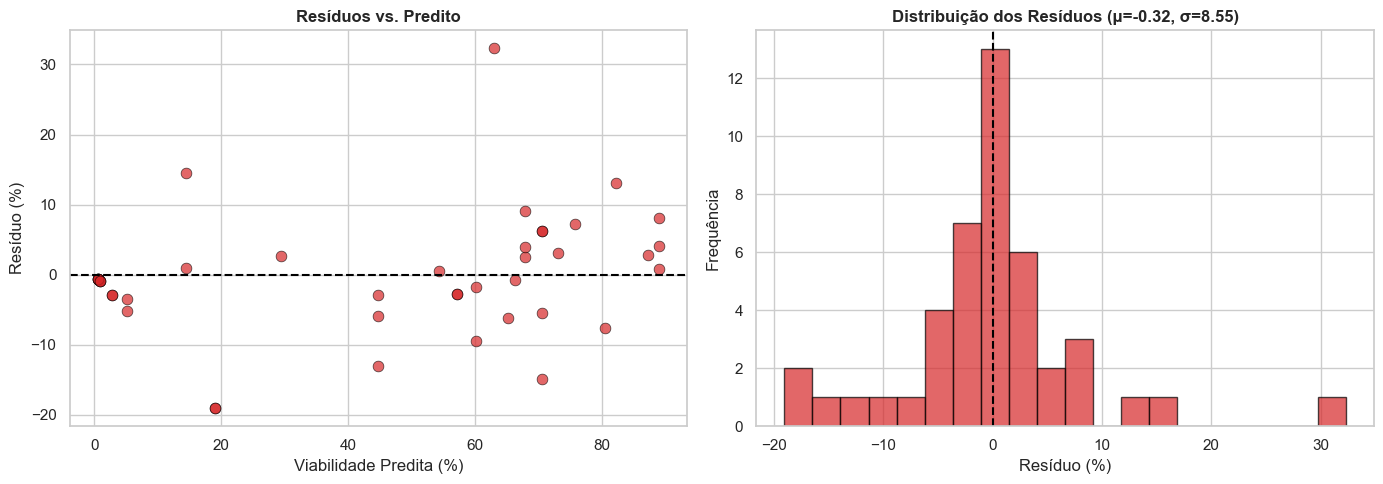

In [16]:
# Gráfico de Resíduos
residuals = y_test - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Resíduos vs Predito
axes[0].scatter(y_pred_test, residuals, alpha=0.7, color='#d62728', s=60, edgecolors='black', linewidths=0.5)
axes[0].axhline(y=0, color='black', linestyle='--', lw=1.5)
axes[0].set_xlabel('Viabilidade Predita (%)')
axes[0].set_ylabel('Resíduo (%)')
axes[0].set_title('Resíduos vs. Predito', fontweight='bold')

# Distribuição dos resíduos
axes[1].hist(residuals, bins=20, color='#d62728', edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='black', linestyle='--', lw=1.5)
axes[1].set_xlabel('Resíduo (%)')
axes[1].set_ylabel('Frequência')
axes[1].set_title(f'Distribuição dos Resíduos (μ={residuals.mean():.2f}, σ={residuals.std():.2f})', fontweight='bold')

plt.tight_layout()
plt.savefig('validation_images/nn_residuos.png', dpi=300)
plt.show()

## K-Fold (K=5)

In [17]:
def train_and_evaluate_fold(X_train_f, y_train_f, X_val_f, y_val_f, input_dim, epochs=1500, patience=80):
    # Preparar tensores
    X_tr = torch.FloatTensor(X_train_f).to(DEVICE)
    y_tr = torch.FloatTensor(y_train_f).unsqueeze(1).to(DEVICE)
    X_val = torch.FloatTensor(X_val_f).to(DEVICE)
    y_val = torch.FloatTensor(y_val_f).unsqueeze(1).to(DEVICE)
    
    loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=32, shuffle=True)
    
    # Modelo novo para cada fold
    fold_model = HepatoCryoNN(input_dim=input_dim).to(DEVICE)
    criterion_f = nn.MSELoss()
    optimizer_f = optim.Adam(fold_model.parameters(), lr=0.001, weight_decay=1e-4)
    scheduler_f = optim.lr_scheduler.ReduceLROnPlateau(optimizer_f, mode='min', factor=0.5, patience=25, min_lr=1e-6)
    
    best_val_loss = float('inf')
    no_improve = 0
    best_state = None
    
    for epoch in range(epochs):
        fold_model.train()
        for X_b, y_b in loader:
            optimizer_f.zero_grad()
            loss = criterion_f(fold_model(X_b), y_b)
            loss.backward()
            optimizer_f.step()
        
        fold_model.eval()
        with torch.no_grad():
            val_loss = criterion_f(fold_model(X_val), y_val).item()
        scheduler_f.step(val_loss)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            no_improve = 0
            best_state = fold_model.state_dict().copy()
        else:
            no_improve += 1
        if no_improve >= patience:
            break
    
    # Carregar melhor estado e avaliar
    fold_model.load_state_dict(best_state)
    fold_model.eval()
    with torch.no_grad():
        y_pred_val = fold_model(X_val).cpu().numpy().flatten()
    
    r2 = r2_score(y_val_f, y_pred_val)
    rmse = np.sqrt(mean_squared_error(y_val_f, y_pred_val))
    return r2, rmse


# Executar K-Fold
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
fold_r2 = []
fold_rmse = []

print('--- VALIDAÇÃO CRUZADA K-FOLD (K=5) ---\n')
for fold, (train_idx, val_idx) in enumerate(kf.split(X_raw)):
    # Preparar dados do fold
    X_tr_raw = X_raw[train_idx]
    X_val_raw = X_raw[val_idx]
    y_tr = y[train_idx]
    y_vl = y[val_idx]
    
    # Feature engineering (fit no treino do fold)
    poly_f = PolynomialFeatures(degree=2, include_bias=False)
    X_tr_poly = poly_f.fit_transform(X_tr_raw)
    X_val_poly = poly_f.transform(X_val_raw)
    
    # Padronização (fit no treino do fold)
    sc_f = StandardScaler()
    X_tr_sc = sc_f.fit_transform(X_tr_poly)
    X_val_sc = sc_f.transform(X_val_poly)
    
    r2, rmse = train_and_evaluate_fold(X_tr_sc, y_tr, X_val_sc, y_vl, input_dim=X_tr_sc.shape[1])
    fold_r2.append(r2)
    fold_rmse.append(rmse)
    print(f'  Fold {fold+1}: R² = {r2:.4f} | RMSE = {rmse:.2f}%')

print(f'  MÉDIA: R² = {np.mean(fold_r2):.4f} (+/- {np.std(fold_r2):.4f})')
print(f'  MÉDIA: RMSE = {np.mean(fold_rmse):.2f}% (+/- {np.std(fold_rmse):.2f}%)')

--- VALIDAÇÃO CRUZADA K-FOLD (K=5) ---

  Fold 1: R² = 0.9319 | RMSE = 9.20%
  Fold 2: R² = 0.9315 | RMSE = 10.09%
  Fold 3: R² = 0.8826 | RMSE = 13.34%
  Fold 4: R² = 0.9122 | RMSE = 10.81%
  Fold 5: R² = 0.9075 | RMSE = 10.34%
  MÉDIA: R² = 0.9131 (+/- 0.0182)
  MÉDIA: RMSE = 10.76% (+/- 1.40%)


## Comparativo Final

In [18]:
# Random Forest (baseline)
rf_model = RandomForestRegressor(n_estimators=200, random_state=SEED)
rf_model.fit(X_train_raw, y_train)
y_pred_rf = rf_model.predict(X_test_raw)
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print(f'Random Forest   -> R² = {r2_rf:.4f} | RMSE = {rmse_rf:.2f}%')
print(f'Rede Neural     -> R² = {r2_test:.4f} | RMSE = {rmse_test:.2f}%')

Random Forest   -> R² = 0.9797 | RMSE = 5.02%
Rede Neural     -> R² = 0.9412 | RMSE = 8.56%


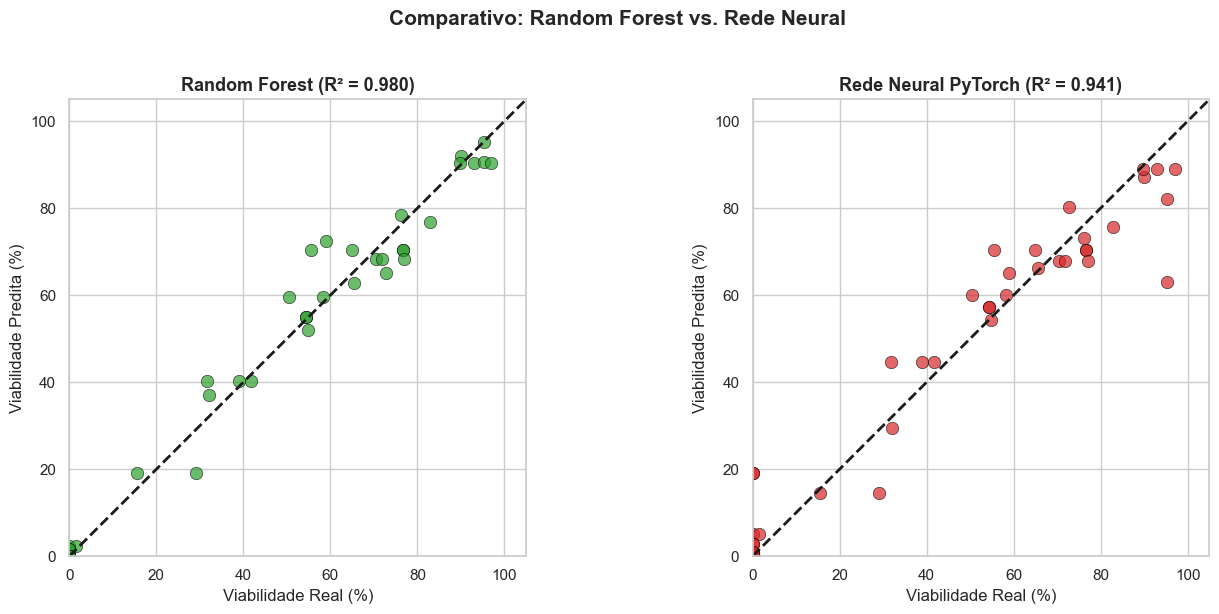

In [19]:
# Gráfico comparativo: dispersão lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

lims = [0, 105]

# Random Forest
axes[0].scatter(y_test, y_pred_rf, alpha=0.7, color='#2ca02c', s=80, edgecolors='black', linewidths=0.5)
axes[0].plot(lims, lims, 'k--', lw=2)
axes[0].set_xlabel('Viabilidade Real (%)')
axes[0].set_ylabel('Viabilidade Predita (%)')
axes[0].set_title(f'Random Forest (R² = {r2_rf:.3f})', fontweight='bold', fontsize=13)
axes[0].set_xlim(lims)
axes[0].set_ylim(lims)
axes[0].set_aspect('equal')

# Rede Neural
axes[1].scatter(y_test, y_pred_test, alpha=0.7, color='#d62728', s=80, edgecolors='black', linewidths=0.5)
axes[1].plot(lims, lims, 'k--', lw=2)
axes[1].set_xlabel('Viabilidade Real (%)')
axes[1].set_ylabel('Viabilidade Predita (%)')
axes[1].set_title(f'Rede Neural PyTorch (R² = {r2_test:.3f})', fontweight='bold', fontsize=13)
axes[1].set_xlim(lims)
axes[1].set_ylim(lims)
axes[1].set_aspect('equal')

plt.suptitle('Comparativo: Random Forest vs. Rede Neural', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('validation_images/nn_comparativo_rf_vs_nn.png', dpi=300, bbox_inches='tight')
plt.show()

## Exportação do Modelo e Pipeline

In [20]:
# Salvar o pipeline completo
pipeline = {
    'poly': poly,       # PolynomialFeatures (já fitado)
    'scaler': scaler,   # StandardScaler (já fitado)
    'input_dim': X_train_scaled.shape[1],
    'metrics': {
        'r2_test': r2_test,
        'rmse_test': rmse_test,
        'r2_train': r2_train,
        'rmse_train': rmse_train,
        'cv_r2_mean': np.mean(fold_r2),
        'cv_r2_std': np.std(fold_r2),
    }
}

joblib.dump(pipeline, '../nn_pipeline.pkl')
torch.save(model.state_dict(), '../nn_model.pth')

print('Arquivos salvos:')
print('  - nn_model.pth (pesos da rede neural)')
print('  - nn_pipeline.pkl (PolynomialFeatures + StandardScaler + métricas)')
print('  - best_nn_model.pth (melhor modelo durante treinamento)')

Arquivos salvos:
  - nn_model.pth (pesos da rede neural)
  - nn_pipeline.pkl (PolynomialFeatures + StandardScaler + métricas)
  - best_nn_model.pth (melhor modelo durante treinamento)
